In [2]:
import tensorflow as tf
import numpy as np
import os


In [3]:
print(tf.__version__)

2.21.0


In [ ]:
from pathlib import Path

In [ ]:
data_dir = Path("../../data/Apple_Data_bereinigt")

print(data_dir.exists())
print(list(data_dir.iterdir())[:10])

MODEL_PATH = Path("../../modelle/final/eigenesCNNmod.keras")

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

True
[WindowsPath('../../data/Apple_Data_bereinigt/Apple__Healthy'), WindowsPath('../../data/Apple_Data_bereinigt/Apple__Rotten')]


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Resizing,
    Rescaling,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Flatten,
    Dense
)

img_size = (64, 64)
batch_size = 32
seed = 42

# 70 % Training 15 % val 15 % test
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names

temp_batches = temp_ds.cardinality().numpy()
val_batches = temp_batches // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

print("Klassen:", class_names)
print("Training Batches:", train_ds.cardinality().numpy())
print("Validation Batches:", val_ds.cardinality().numpy())
print("Test Batches:", test_ds.cardinality().numpy())

Found 4751 files belonging to 2 classes.
Using 3326 files for training.
Found 4751 files belonging to 2 classes.
Using 1425 files for validation.
Klassen: ['Apple__Healthy', 'Apple__Rotten']
Training Batches: 104
Validation Batches: 22
Test Batches: 23


In [17]:
model = Sequential()

model.add(Resizing(64, 64))
model.add(Rescaling(1/255.0))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation="relu"))

# 2 Klassen: Apple__Healthy und Apple__Rotten
model.add(Dense(2, activation='softmax'))

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_2 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
es=EarlyStopping(patience=3)
mc=ModelCheckpoint(filepath='MODEL_PATH',save_best_only=True)

In [20]:
model.fit(train_ds,validation_data=val_ds,epochs=10, callbacks=[es,mc])

Epoch 1/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 64s 608ms/step - accuracy: 0.8175 - loss: 0.4331 - val_accuracy: 0.8551 - val_loss: 0.3490
Epoch 2/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 60s 571ms/step - accuracy: 0.8482 - loss: 0.3563 - val_accuracy: 0.8636 - val_loss: 0.3354
Epoch 3/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 59s 566ms/step - accuracy: 0.8677 - loss: 0.3260 - val_accuracy: 0.8878 - val_loss: 0.3216
Epoch 4/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 68s 654ms/step - accuracy: 0.8737 - loss: 0.3043 - val_accuracy: 0.8551 - val_loss: 0.3695
Epoch 5/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 77s 740ms/step - accuracy: 0.8764 - loss: 0.2939 - val_accuracy: 0.9062 - val_loss: 0.2632
Epoch 6/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 72s 639ms/step - accuracy: 0.8897 - loss: 0.2728 - val_accuracy: 0.9077 - val_loss: 0.2452
Epoch 7/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 87s 836ms/step - accuracy: 0.8903 - loss: 0.2761 - val_accuracy: 0.8864 - val_loss: 0.2772
Epoch 8/10
104/104 ━━━━━━━━━━━━━━━━━━━━ 65s 626ms/step - accuracy: 0.8966 - loss: 0

In [21]:
model.load_weights('bestModel.keras')
score = model.evaluate(test_ds)

23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 377ms/step - accuracy: 0.9126 - loss: 0.2316


In [22]:
!python -m pip install scikit-learn

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step
[[236  42]
 [ 12 431]]
                precision    recall  f1-score   support

Apple__Healthy       0.

[[236  42]
 [ 12 431]]


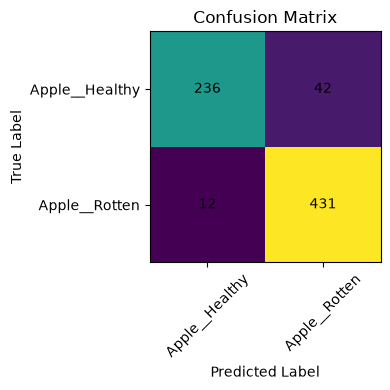

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()